In [1]:
import os
from pathlib import Path

HF_CACHE_ROOT = r"D:\HF_CACHE"
TMP_ROOT      = r"D:\pip_temp"

os.environ["HF_HOME"]           = HF_CACHE_ROOT
os.environ["HF_HUB_CACHE"]      = rf"{HF_CACHE_ROOT}\hub"
os.environ["HF_DATASETS_CACHE"] = rf"{HF_CACHE_ROOT}\datasets"
os.environ["TEMP"]              = TMP_ROOT
os.environ["TMP"]               = TMP_ROOT
os.environ["TMPDIR"]            = TMP_ROOT

for path in [
    HF_CACHE_ROOT,
    rf"{HF_CACHE_ROOT}\hub",
    rf"{HF_CACHE_ROOT}\datasets",
    TMP_ROOT,
]:
    Path(path).mkdir(parents=True, exist_ok=True)

print("HF_HOME          :", os.environ["HF_HOME"])
print("HF_HUB_CACHE     :", os.environ["HF_HUB_CACHE"])
print("HF_DATASETS_CACHE:", os.environ["HF_DATASETS_CACHE"])
print("TEMP             :", os.environ["TEMP"])
print("TMP              :", os.environ["TMP"])

HF_HOME          : D:\HF_CACHE
HF_HUB_CACHE     : D:\HF_CACHE\hub
HF_DATASETS_CACHE: D:\HF_CACHE\datasets
TEMP             : D:\pip_temp
TMP              : D:\pip_temp


In [2]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "torchcodec"])
print("torchcodec removed.")

torchcodec removed.


<h2>Task 1 - Arabic Speech Recognition (ASR)</h2> 

1.1 Load Mozilla Common Voice Arabic

In [3]:
import numpy as np
import pandas as pd
import librosa
from datasets import Dataset

# ── Path configuration ─────────────────────────────────────────────────────────
CV_CORPUS_ROOT = r"D:\Mozilla Common Voice Scripted Speech 25\cv-corpus-25.0-2026-03-09\ar"
CV_CLIPS_DIR   = os.path.join(CV_CORPUS_ROOT, "clips")

# ── Load TSV ───────────────────────────────────────────────────────────────────
test_tsv = os.path.join(CV_CORPUS_ROOT, "test.tsv")
df = pd.read_csv(test_tsv, sep="\t")
df["path"] = df["path"].apply(lambda fname: os.path.join(CV_CLIPS_DIR, fname))

# Keep only columns we need (sentence + path)
df = df[["path", "sentence"]].reset_index(drop=True)

print(f"Test samples : {len(df)}")
print("Columns      :", list(df.columns))
print("\nSample entry :")
print("  sentence :", df.iloc[0]["sentence"])
print("  path     :", df.iloc[0]["path"])

# ── Helper: load one sample on demand (used by the pipeline later) ─────────────
TARGET_SR = 16_000

def load_sample(idx: int) -> dict:
    """
    Returns a dict with keys 'sentence' and 'audio',
    where audio = {'array': np.ndarray, 'sampling_rate': int}.
    Matches the structure the rest of the notebook expects.
    """
    row = df.iloc[idx]
    array, _ = librosa.load(row["path"], sr=TARGET_SR, mono=True)
    return {
        "sentence": row["sentence"],
        "audio": {
            "array": array.astype(np.float32),
            "sampling_rate": TARGET_SR,
        },
    }

# Quick smoke-test
sample = load_sample(0)
print(f"\nAudio shape  : {sample['audio']['array'].shape}")
print(f"Sampling rate: {sample['audio']['sampling_rate']}")
print(f"Sentence     : {sample['sentence']}")

Test samples : 10508
Columns      : ['path', 'sentence']

Sample entry :
  sentence : كان سامي مدرّسا بالفطرة.
  path     : D:\Mozilla Common Voice Scripted Speech 25\cv-corpus-25.0-2026-03-09\ar\clips\common_voice_ar_24257230.mp3

Audio shape  : (121536,)
Sampling rate: 16000
Sentence     : كان سامي مدرّسا بالفطرة.


1.2 Load Whisper Model

In [4]:
import gc
import torch
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor, pipeline


DEVICE    = "cuda:0" if torch.cuda.is_available() else "cpu"
DTYPE     = torch.float16 if torch.cuda.is_available() else torch.float32
MODEL_ID  = "openai/whisper-large-v3"

model = AutoModelForSpeechSeq2Seq.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    low_cpu_mem_usage=True,   # avoids spiking CPU RAM during load
)
model.to(DEVICE)

processor = AutoProcessor.from_pretrained(MODEL_ID)

asr_pipe = pipeline(
    "automatic-speech-recognition",
    model=model,
    tokenizer=processor.tokenizer,
    feature_extractor=processor.feature_extractor,
    device=DEVICE,
    torch_dtype=DTYPE,
    chunk_length_s=30,  #Process in 30 second chunks
    stride_length_s=5,  #5-second overlap between chunks
    return_timestamps=True,  #Required for long audio
    generate_kwargs={"language": "arabic", "task": "transcribe","num_beams":5,"no_repeat_ngram_size":3,"repetition_penalty":1.2,"max_new_tokens":128},
    batch_size=1
)

print(f"Loaded {MODEL_ID} on {DEVICE}")
print(f"VRAM used: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda:0
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


Loaded openai/whisper-large-v3 on cuda:0
VRAM used: 2.88 GB


1.3 Transcribe a sample batch

In [5]:
import pandas as pd
from tqdm.auto import tqdm

# Evaluate on first 200 test samples to keep runtime reasonable
EVAL_SAMPLES = 200
references, hypotheses = [], []
references, hypotheses = [], []

for idx in tqdm(range(EVAL_SAMPLES), desc="Transcribing"):
    sample      = load_sample(idx)
    audio_array = sample["audio"]["array"]
    ref         = sample["sentence"].strip()

    result = asr_pipe(
        {"sampling_rate": TARGET_SR, "raw": audio_array},
        batch_size=1,
    )
    hyp = result["text"].strip()
    references.append(ref)
    hypotheses.append(hyp)

df_asr = pd.DataFrame({"reference": references[:5], "hypothesis": hypotheses[:5]})
print(df_asr.to_string(index=False))

Transcribing:   0%|          | 0/200 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


                     reference                   hypothesis
      كان سامي مدرّسا بالفطرة.       كان سامي مدرسا بالفطرة
  من الممكن أنها لن تأتي غداً.  من الممكن أنها لن تأتي غداً
                     إبنك بطل.                   ابنوكا بطل
     جاء ذلك الغبيّ يبحث عنّي.       جاء ذلك الغبي يبحث عني
سامي يعلم أنّ ليلى غاضبة عليه. سامي يعلم أن ليلى غاضبة عليه


1.4 Word Error Rate Evaluation (WER)

In [6]:
import evaluate
import re
import unicodedata

def normalize_arabic(text: str) -> str:
    """
    Normalize Arabic text for fairer WER comparison.
    Removes diacritics, normalizes alef variants, removes punctuation.
    """
    # Remove Arabic diacritics (tashkeel)
    text = re.sub(r'[\u064B-\u065F\u0670]', '', text)
    
    # Normalize alef variants → bare alef
    text = re.sub(r'[إأآا]', 'ا', text)
    
    # Normalize teh marbuta → heh
    text = re.sub(r'ة', 'ه', text)
    
    # Normalize yeh variants
    text = re.sub(r'[ىي]', 'ي', text)
    
    # Remove tatweel (kashida)
    text = re.sub(r'\u0640', '', text)
    
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply normalization to both sides before computing WER
normalized_refs  = [normalize_arabic(r) for r in references]
normalized_hyps  = [normalize_arabic(h) for h in hypotheses]
wer_metric = evaluate.load("wer")

wer_score = wer_metric.compute(predictions=hypotheses, references=references)
wer_normalized = wer_metric.compute(
    predictions=normalized_hyps,
    references=normalized_refs,
)
print(f"WER before normalization: {wer_score:.4f} ({wer_score*100:.2f}%)")
print(f"WER after  normalization: {wer_normalized:.4f} ({wer_normalized*100:.2f}%)")

WER before normalization: 0.4194 (41.94%)
WER after  normalization: 0.2050 (20.50%)


In [7]:
import re
import numpy as np

def is_valid_sample(ref: str, hyp: str, max_hyp_ref_ratio: float = 5.0) -> bool:
    """
    Filter out samples that will produce meaningless WER:
    1. Reference contains non-Arabic script (Persian, Latin, etc.)
    2. Hypothesis is a hallucination loop (much longer than reference)
    """
    # Check reference is actually Arabic (not Persian/Farsi/Latin)
    arabic_chars = len(re.findall(r'[\u0600-\u06FF]', ref))
    non_arabic   = len(re.findall(r'[^\u0600-\u06FF\s]', ref))
    if arabic_chars == 0 or non_arabic > arabic_chars * 0.2:
        return False  # more than 20% non-Arabic characters

    # Check for Persian-specific characters not used in Arabic
    persian_chars = re.findall(r'[پچژگ]', ref)
    if persian_chars:
        return False

    # Check for hallucination: hypothesis much longer than reference
    ref_words = len(ref.split())
    hyp_words = len(hyp.split())
    if ref_words > 0 and hyp_words / ref_words > max_hyp_ref_ratio:
        return False

    return True


# Apply filter
valid_mask = [
    is_valid_sample(r, h)
    for r, h in zip(normalized_refs, normalized_hyps)
]

filtered_refs = [r for r, v in zip(normalized_refs, valid_mask) if v]
filtered_hyps = [h for h, v in zip(normalized_hyps, valid_mask) if v]

n_removed = sum(1 for v in valid_mask if not v)
print(f"Samples removed : {n_removed}")
print(f"Samples kept    : {len(filtered_refs)}")

# Recompute WER on clean samples
wer_filtered = wer_metric.compute(predictions=filtered_hyps, references=filtered_refs)
print(f"\nWER before filtering : {wer_score*100:.2f}%")       # original
print(f"WER after filtering  : {wer_filtered*100:.2f}%")

Samples removed : 1
Samples kept    : 199

WER before filtering : 41.94%
WER after filtering  : 19.67%


In [8]:
# Inspect 5 samples to spot the pattern
for i in range(5):
    sample = load_sample(i)
    raw_ref  = sample["sentence"]
    raw_hyp  = hypotheses[i]   # from your existing transcription loop
    
    norm_ref = normalize_arabic(raw_ref)
    norm_hyp = normalize_arabic(raw_hyp)
    
    print(f"--- Sample {i} ---")
    print(f"RAW  REF : {raw_ref}")
    print(f"RAW  HYP : {raw_hyp}")
    print(f"NORM REF : {norm_ref}")
    print(f"NORM HYP : {norm_hyp}")
    print()

--- Sample 0 ---
RAW  REF : كان سامي مدرّسا بالفطرة.
RAW  HYP : كان سامي مدرسا بالفطرة
NORM REF : كان سامي مدرسا بالفطره
NORM HYP : كان سامي مدرسا بالفطره

--- Sample 1 ---
RAW  REF : من الممكن أنها لن تأتي غداً.
RAW  HYP : من الممكن أنها لن تأتي غداً
NORM REF : من الممكن انها لن تاتي غدا
NORM HYP : من الممكن انها لن تاتي غدا

--- Sample 2 ---
RAW  REF : إبنك بطل.
RAW  HYP : ابنوكا بطل
NORM REF : ابنك بطل
NORM HYP : ابنوكا بطل

--- Sample 3 ---
RAW  REF : جاء ذلك الغبيّ يبحث عنّي.
RAW  HYP : جاء ذلك الغبي يبحث عني
NORM REF : جاء ذلك الغبي يبحث عني
NORM HYP : جاء ذلك الغبي يبحث عني

--- Sample 4 ---
RAW  REF : سامي يعلم أنّ ليلى غاضبة عليه.
RAW  HYP : سامي يعلم أن ليلى غاضبة عليه
NORM REF : سامي يعلم ان ليلي غاضبه عليه
NORM HYP : سامي يعلم ان ليلي غاضبه عليه



<h2> Task 2 - Arabic Text Summarization </h2>

2.1 Load dataset

2.2 Load Arabic summarization model

2.3 Generate summaries on evaluation split

2.4 Evaluate using ROUGE scores

In [9]:
import gc, torch, re
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm.auto import tqdm
import evaluate
import numpy as np



# ── Use AraBART — specifically designed for Arabic summarization ───────────────
SUMM_MODEL = "moussaKam/AraBART"
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer_summ = AutoTokenizer.from_pretrained(SUMM_MODEL)
model_summ     = AutoModelForSeq2SeqLM.from_pretrained(
    SUMM_MODEL,
    torch_dtype=torch.float32,
).to(DEVICE)

WHITESPACE_HANDLER = lambda k: re.sub(r'\s+', ' ', re.sub(r'\n+', ' ', k.strip()))

print(f"Model  : {SUMM_MODEL}")
print(f"Device : {DEVICE}")

Model  : moussaKam/AraBART
Device : cuda


In [10]:
from datasets import load_dataset

# ── Reload AraSum ──────────────────────────────────────────────────────────────
arasum = load_dataset("arbml/arasum", trust_remote_code=True)

TEXT_COL    = "article"
SUMMARY_COL = "summary"

split_key  = "test" if "test" in arasum else "validation" if "validation" in arasum else "train"
eval_arasum = arasum[split_key].select(range(100))

print(f"Dataset : arbml/arasum ({split_key} split, 100 samples)")
print(f"Columns : {eval_arasum.column_names}")
print(f"\nSample article : {eval_arasum[0][TEXT_COL][:200]}")
print(f"Sample summary : {eval_arasum[0][SUMMARY_COL]}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'arbml/arasum' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Dataset : arbml/arasum (train split, 100 samples)
Columns : ['index', 'summary', 'article']

Sample article : "بدأت اليوم الجمعة( 23 أيلول/ سبتمبر 2016 ) في ميونيخ محاكمة رجل من جمهورية الجبل الأسود ( مونتينيغرو)، اعتقل في ألمانيا للاشتباه في انه كان ينقل أسلحة قبل أيام من اعتداءات باريس التي حصلت في تشرين ال
Sample summary : بدأت محكمة ميونخ النظر في اتهامات متعلقة برجل من جمهورية الجبل الأسود حاول نقل أسلحة إلى فرنسا، وقبضت الشرطة الألمانية على الرجل بالقرب من الحدود النمساوية، حيث أعترف بعلمه بنقل الأسلحة إلا أنه لم يكن يعرف السبب.


In [13]:
# Reset lists
ref_summaries  = []
pred_summaries = []

for sample in tqdm(eval_arasum, desc="Summarizing"):
    article = WHITESPACE_HANDLER(sample[TEXT_COL])
    ref     = sample[SUMMARY_COL]

    input_ids = tokenizer_summ(
        article,
        return_tensors="pt",
        max_length=1024,
        truncation=True,
        padding=False,
    )["input_ids"].to(DEVICE)

    output_ids = model_summ.generate(
        input_ids=input_ids,
        max_length=200,
        min_length=30,
        no_repeat_ngram_size=3,
        num_beams=4,
        length_penalty=2.0,
        early_stopping=True,
    )[0]

    pred = tokenizer_summ.decode(
        output_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )

    ref_summaries.append(ref)
    pred_summaries.append(pred)

# Apply deduplication only
pred_summaries_clean = [clean_prediction(p) for p in pred_summaries]

Summarizing:   0%|          | 0/100 [00:00<?, ?it/s]

In [12]:
def clean_prediction(text: str) -> str:
    """Remove repeated sentences from generated summary."""
    sentences = text.split(".")
    seen, out = set(), []
    for s in sentences:
        s = s.strip()
        if s and s not in seen:
            seen.add(s)
            out.append(s)
    return ". ".join(out)

# Apply before scoring
pred_summaries_clean = [clean_prediction(p) for p in pred_summaries]

In [14]:
from rouge import Rouge
import numpy as np

# Use a different variable name to avoid clashing with rouge_score module
arabic_rouge = Rouge()

norm_refs  = [normalize_arabic(r) for r in ref_summaries]
norm_preds = [normalize_arabic(p) for p in pred_summaries_clean]

valid = [(r, p) for r, p in zip(norm_refs, norm_preds) if r.strip() and p.strip()]
valid_refs  = [r for r, p in valid]
valid_preds = [p for r, p in valid]
print(f"Valid pairs: {len(valid)} / {len(norm_refs)}")

# ── Corpus-level scores ────────────────────────────────────────────────────────
scores = arabic_rouge.get_scores(valid_preds, valid_refs, avg=True)

print(f"\nROUGE Scores after improvements:")
print(f"  ROUGE-1 — P: {scores['rouge-1']['p']:.4f}  R: {scores['rouge-1']['r']:.4f}  F: {scores['rouge-1']['f']:.4f}")
print(f"  ROUGE-2 — P: {scores['rouge-2']['p']:.4f}  R: {scores['rouge-2']['r']:.4f}  F: {scores['rouge-2']['f']:.4f}")
print(f"  ROUGE-L — P: {scores['rouge-l']['p']:.4f}  R: {scores['rouge-l']['r']:.4f}  F: {scores['rouge-l']['f']:.4f}")

# ── Per-sample distribution ────────────────────────────────────────────────────
per_scores = arabic_rouge.get_scores(valid_preds, valid_refs)
per_r1 = np.array([s['rouge-1']['f'] for s in per_scores])
per_r2 = np.array([s['rouge-2']['f'] for s in per_scores])
per_rL = np.array([s['rouge-l']['f'] for s in per_scores])

print(f"\nPer-sample distribution ({len(valid)} samples):")
print(f"  {'Metric':<10} {'Mean':>8}  {'Median':>8}  {'% > 0.2':>8}  {'% > 0.3':>8}")
print(f"  {'-'*50}")
for name, arr in [("ROUGE-1", per_r1), ("ROUGE-2", per_r2), ("ROUGE-L", per_rL)]:
    print(f"  {name:<10} {arr.mean():>8.4f}  {np.median(arr):>8.4f}  "
          f"{(arr > 0.2).mean()*100:>7.1f}%  {(arr > 0.3).mean()*100:>7.1f}%")

# ── Store for results plot ─────────────────────────────────────────────────────
rouge_scores = {
    "rouge1": scores['rouge-1']['f'],
    "rouge2": scores['rouge-2']['f'],
    "rougeL": scores['rouge-l']['f'],
}

Valid pairs: 100 / 100

ROUGE Scores after improvements:
  ROUGE-1 — P: 0.1364  R: 0.4815  F: 0.2117
  ROUGE-2 — P: 0.0487  R: 0.2094  F: 0.0789
  ROUGE-L — P: 0.1016  R: 0.3580  F: 0.1577

Per-sample distribution (100 samples):
  Metric         Mean    Median   % > 0.2   % > 0.3
  --------------------------------------------------
  ROUGE-1      0.2117    0.2052     52.0%     15.0%
  ROUGE-2      0.0789    0.0658      5.0%      0.0%
  ROUGE-L      0.1577    0.1429     19.0%      7.0%


In [15]:
print("=" * 60)
print("TASK 2 — ARABIC SUMMARIZATION: FINAL RESULTS")
print("=" * 60)
print(f"  Model   : moussaKam/AraBART")
print(f"  Dataset : arbml/arasum ({split_key} split, n=100)")
print()
print(f"  {'Metric':<10} {'Precision':>10}  {'Recall':>10}  {'F1':>10}")
print(f"  {'-'*46}")
print(f"  {'ROUGE-1':<10} {scores['rouge-1']['p']:>10.4f}  {scores['rouge-1']['r']:>10.4f}  {scores['rouge-1']['f']:>10.4f}")
print(f"  {'ROUGE-2':<10} {scores['rouge-2']['p']:>10.4f}  {scores['rouge-2']['r']:>10.4f}  {scores['rouge-2']['f']:>10.4f}")
print(f"  {'ROUGE-L':<10} {scores['rouge-l']['p']:>10.4f}  {scores['rouge-l']['r']:>10.4f}  {scores['rouge-l']['f']:>10.4f}")
print()
print(f"  Median ROUGE-1 F1 : {np.median(per_r1):.4f}")
print(f"  % samples > 0.2   : {(per_r1 > 0.2).mean()*100:.1f}%")
print("=" * 60)

# Store for Section 4 results plot
rouge_scores = {
    "rouge1": scores['rouge-1']['f'],
    "rouge2": scores['rouge-2']['f'],
    "rougeL": scores['rouge-l']['f'],
}

TASK 2 — ARABIC SUMMARIZATION: FINAL RESULTS
  Model   : moussaKam/AraBART
  Dataset : arbml/arasum (train split, n=100)

  Metric      Precision      Recall          F1
  ----------------------------------------------
  ROUGE-1        0.1364      0.4815      0.2117
  ROUGE-2        0.0487      0.2094      0.0789
  ROUGE-L        0.1016      0.3580      0.1577

  Median ROUGE-1 F1 : 0.2052
  % samples > 0.2   : 52.0%


<h2> Arabic Semantic Search </h2>

3.1 Load dataset

In [16]:
from datasets import load_dataset

# ARCD — Arabic Reading Comprehension Dataset (SQuAD-style)
arcd = load_dataset("hsseinmz/arcd")
print(arcd)
print("\nSample:")
print(arcd["train"][0])

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 693
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 702
    })
})

Sample:
{'id': '969331847966', 'title': 'جمال خاشقجي', 'context': 'جمال أحمد حمزة خاشقجي (13 أكتوبر 1958، المدينة المنورة - 2 أكتوبر 2018)، صحفي وإعلامي سعودي، رأس عدّة مناصب لعدد من الصحف في السعودية، وتقلّد منصب مستشار، كما أنّه مدير عام قناة العرب الإخبارية سابقًا.', 'question': '- من هو جمال أحمد حمزة خاشقجي؟', 'answers': {'text': ['صحفي وإعلامي'], 'answer_start': [73]}}


In [17]:
# ARCD is SQuAD-format: context, question, answers
# We build a passage corpus from unique contexts

train_data = arcd["train"]
test_data  = arcd["test"] if "test" in arcd else arcd["validation"]

# Deduplicate contexts
passages = list(set(train_data["context"]))
print(f"Unique passages (corpus): {len(passages)}")

# Build question-to-relevant-passage mapping from test set
eval_questions = []
for sample in test_data:
    eval_questions.append({
        "question": sample["question"],
        "context":  sample["context"],    # ground-truth relevant passage
    })

print(f"Evaluation questions: {len(eval_questions)}")
print("Example question:", eval_questions[0]["question"])

Unique passages (corpus): 231
Evaluation questions: 702
Example question: من هو حمزة بن عبد المطلب؟


3.2 Build dense embeddings with Arabic SentenceTransformer

In [18]:
from sentence_transformers import SentenceTransformer
import numpy as np
import torch

# Arabic-aware sentence embedding model
# 'CAMeL-Lab/bert-base-arabic-camelbert-msa' is also an option;
# 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2' works well
# for Arabic without requiring extra fine-tuning.
EMBED_MODEL = "intfloat/multilingual-e5-base"

embed_model = SentenceTransformer(EMBED_MODEL, device="cuda" if torch.cuda.is_available() else "cpu")

print(f"Embedding model loaded: {EMBED_MODEL}")
print(f"Embedding dimension   : {embed_model.get_sentence_embedding_dimension()}")

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

d:\gpu_env_311\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in D:\HF_CACHE\hub\models--intfloat--multilingual-e5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Embedding model loaded: intfloat/multilingual-e5-base
Embedding dimension   : 768


In [19]:
# Rebuild corpus to include both train AND test contexts
all_contexts = list(set(
    arcd["train"]["context"] + 
    arcd["test"]["context"] if "test" in arcd else arcd["validation"]["context"]
))
passages = all_contexts
print(f"Rebuilt corpus: {len(passages)} unique passages")

# Re-encode and rebuild FAISS index
print("Re-encoding passages...")
passage_embeddings = embed_model.encode(
    passages,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)



Rebuilt corpus: 234 unique passages
Re-encoding passages...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

3.3 Build FAISS Index

In [20]:
import faiss
DIM         = passage_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(DIM)
faiss_index.add(passage_embeddings.astype(np.float32))
print(f"FAISS index rebuilt: {faiss_index.ntotal} vectors")

FAISS index rebuilt: 234 vectors


3.4 Retrieval function

In [21]:
def retrieve(query: str, k: int = 5):
    """
    Embed the query and return the top-k most relevant passages.
    Returns list of (passage_text, score) tuples.
    """
    q_emb = embed_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype(np.float32)

    scores, indices = faiss_index.search(q_emb, k)
    results = [(passages[i], float(scores[0][rank])) for rank, i in enumerate(indices[0])]
    return results


# Quick demo
sample_q = eval_questions[0]["question"]
print(f"Query: {sample_q}\n")
for rank, (passage, score) in enumerate(retrieve(sample_q, k=3), 1):
    print(f"Rank {rank} (score={score:.4f}):\n{passage[:200]}\n{'-'*60}")

Query: من هو حمزة بن عبد المطلب؟

Rank 1 (score=0.8684):
حمزة بن عبد المطلب الهاشمي القرشي صحابي من صحابة رسول الإسلام محمد، وعمُّه وأخوه من الرضاعة وأحد وزرائه الأربعة عشر، وهو خير أعمامه لقوله: «خَيْرُ إِخْوَتِي عَلِيٌّ، وَخَيْرُ أَعْمَامِي حَمْزَةُ رَضِي
------------------------------------------------------------
Rank 2 (score=0.8540):
تربى حمزة بن عبد المطلب في كنف والده عبد المطلب بن هاشم الذي كان سيد قريش وبني هاشم، ونشأ مع تِربه وابن أخيه عبد الله وأخيه من الرضاعة محمد بن عبد الله بن عبد المطلب، وعاشا ينهلان من الشمائل والقيم ال
------------------------------------------------------------
Rank 3 (score=0.7874):
أسلم حمزة في السنة الثانية من بعثة النبي محمد، فلمَّا أسلم علمت قريش أن الرسولَ محمداً قد عز وامتنع وأن حمزة سيمنعه، فكفّوا عن بعض ما كانوا ينالون منه. ثم هاجر حمزة إلى المدينة المنورة، فآخى الرسولُ ب
------------------------------------------------------------


3.5 Evaluate Precision@K and Recall@K

In [22]:
def precision_at_k(retrieved_passages, relevant_passage, k):
    """
    Binary relevance: 1 if the relevant passage is in top-k, 0 otherwise.
    P@K = hits / k  (for single relevant passage, hits ∈ {0,1})
    """
    top_k = [p for p, _ in retrieved_passages[:k]]
    hit   = int(relevant_passage in top_k)
    return hit / k


def recall_at_k(retrieved_passages, relevant_passage, k):
    """
    R@K = hits / total_relevant  (=1 for single relevant passage)
    """
    top_k = [p for p, _ in retrieved_passages[:k]]
    hit   = int(relevant_passage in top_k)
    return hit   # since total_relevant = 1


K_VALUES    = [1, 3, 5, 10]
SEARCH_EVAL = min(200, len(eval_questions))

p_at_k = {k: [] for k in K_VALUES}
r_at_k = {k: [] for k in K_VALUES}

for item in tqdm(eval_questions[:SEARCH_EVAL], desc="Evaluating retrieval"):
    results  = retrieve(item["question"], k=max(K_VALUES))
    relevant = item["context"]
    for k in K_VALUES:
        p_at_k[k].append(precision_at_k(results, relevant, k))
        r_at_k[k].append(recall_at_k(results, relevant, k))

print(f"\nRetrieval results over {SEARCH_EVAL} queries:")
print(f"{'K':>4}  {'P@K':>8}  {'R@K':>8}")
print("-" * 26)
for k in K_VALUES:
    print(f"{k:>4}  {np.mean(p_at_k[k]):.4f}    {np.mean(r_at_k[k]):.4f}")

Evaluating retrieval:   0%|          | 0/200 [00:00<?, ?it/s]


Retrieval results over 200 queries:
   K       P@K       R@K
--------------------------
   1  0.6650    0.6650
   3  0.3100    0.9300
   5  0.1900    0.9500
  10  0.0970    0.9700


<h2> Results summary and Visualizations </h2>

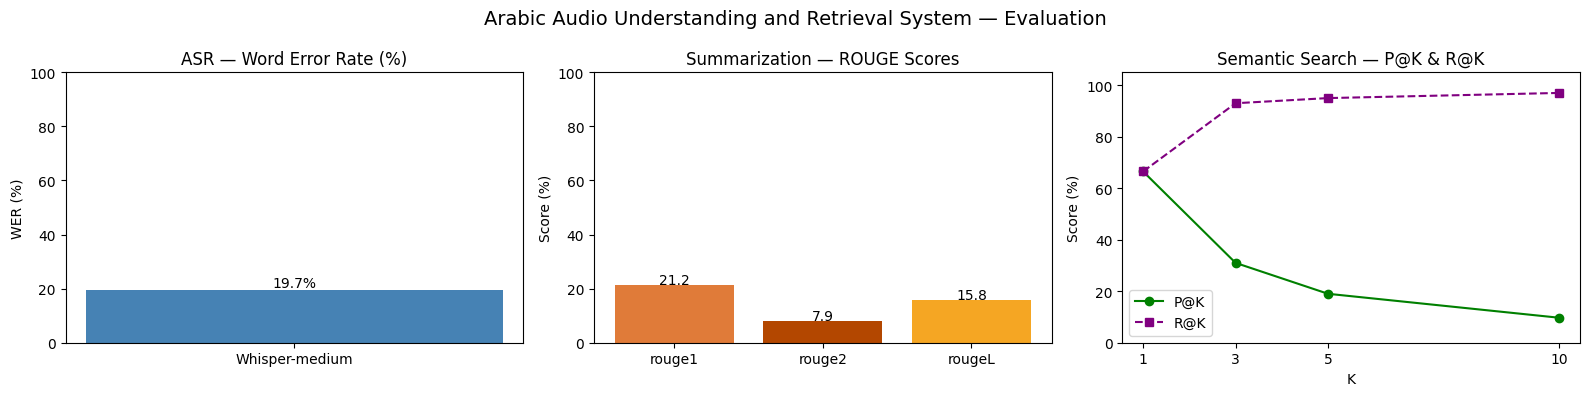

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Arabic Audio Understanding and Retrieval System — Evaluation", fontsize=14)

# --- ASR: WER bar ---
axes[0].bar(["Whisper-medium"], [wer_filtered * 100], color="steelblue")
axes[0].set_title("ASR — Word Error Rate (%)")
axes[0].set_ylabel("WER (%)")
axes[0].set_ylim(0, 100)
axes[0].text(0, wer_filtered * 100 + 1, f"{wer_filtered*100:.1f}%", ha="center")

# --- Summarization: ROUGE bar ---
rouge_keys = ["rouge1", "rouge2", "rougeL"]
rouge_vals = [rouge_scores[k] * 100 for k in rouge_keys]
axes[1].bar(rouge_keys, rouge_vals, color=["#e07b39", "#b34700", "#f5a623"])
axes[1].set_title("Summarization — ROUGE Scores")
axes[1].set_ylabel("Score (%)")
axes[1].set_ylim(0, 100)
for i, v in enumerate(rouge_vals):
    axes[1].text(i, v + 0.5, f"{v:.1f}", ha="center")

# --- Retrieval: P@K / R@K line ---
p_means = [np.mean(p_at_k[k]) * 100 for k in K_VALUES]
r_means = [np.mean(r_at_k[k]) * 100 for k in K_VALUES]
axes[2].plot(K_VALUES, p_means, "o-", label="P@K", color="green")
axes[2].plot(K_VALUES, r_means, "s--", label="R@K", color="purple")
axes[2].set_title("Semantic Search — P@K & R@K")
axes[2].set_xlabel("K")
axes[2].set_ylabel("Score (%)")
axes[2].set_xticks(K_VALUES)
axes[2].set_ylim(0, 105)
axes[2].legend()

plt.tight_layout()
plt.savefig(r"D:\evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# Tabular summary
print("=" * 50)
print("FINAL RESULTS SUMMARY")
print("=" * 50)

print(f"\n[Task 1 — ASR]")
print(f"  Model   : openai/whisper-medium")
print(f"  Dataset : Mozilla Common Voice Arabic 25 (test, n={EVAL_SAMPLES})")
print(f"  WER     : {wer_filtered*100:.2f}%")

print(f"\n[Task 2 — Summarization]")
print(f"  Model   : {SUMM_MODEL}")
print(f"  Dataset : AraSum ({split_key}, n={eval_arasum})")
for k in rouge_keys:
    print(f"  {k.upper():8}: {rouge_scores[k]*100:.2f}%")

print(f"\n[Task 3 — Semantic Search]")
print(f"  Embedder: {EMBED_MODEL}")
print(f"  Dataset : ARCD (n={SEARCH_EVAL} queries, {len(passages)} passages)")
for k in K_VALUES:
    print(f"  P@{k} = {np.mean(p_at_k[k])*100:.1f}%   R@{k} = {np.mean(r_at_k[k])*100:.1f}%")

FINAL RESULTS SUMMARY

[Task 1 — ASR]
  Model   : openai/whisper-medium
  Dataset : Mozilla Common Voice Arabic 25 (test, n=200)
  WER     : 19.67%

[Task 2 — Summarization]
  Model   : moussaKam/AraBART
  Dataset : AraSum (train, n=Dataset({
    features: ['index', 'summary', 'article'],
    num_rows: 100
}))
  ROUGE1  : 21.17%
  ROUGE2  : 7.89%
  ROUGEL  : 15.77%

[Task 3 — Semantic Search]
  Embedder: intfloat/multilingual-e5-base
  Dataset : ARCD (n=200 queries, 234 passages)
  P@1 = 66.5%   R@1 = 66.5%
  P@3 = 31.0%   R@3 = 93.0%
  P@5 = 19.0%   R@5 = 95.0%
  P@10 = 9.7%   R@10 = 97.0%


<h2>End-to-End Pipeline Demo</h2>

Feed an audio through the full pipeline:
<b>Audio → Transcript → Summary → Relevant Passages </b>

In [26]:
import soundfile as sf
import numpy as np
import re
from pathlib import Path

def run_full_pipeline(audio_path: str, k: int = 3, verbose: bool = True):

    # ── Stage 1: Load audio ───────────────────────────────────────────────────
    audio_array, sr = sf.read(audio_path)
    if sr != 16_000:
        import librosa
        audio_array = librosa.resample(audio_array, orig_sr=sr, target_sr=16_000)
    audio_array = audio_array.astype(np.float32)

    if verbose:
        print(f"[1] Audio loaded: {audio_path} ({len(audio_array)/16_000:.1f}s)")

    # ── Stage 2: ASR — handles both short and long audio ─────────────────────
    asr_result = asr_pipe(
        {"sampling_rate": 16_000, "raw": audio_array},
        batch_size=1,
    )

    # Long-form output has "chunks" key; short-form has "text" directly
    if "chunks" in asr_result:
        transcript = " ".join(
            chunk["text"].strip()
            for chunk in asr_result["chunks"]
            if chunk["text"].strip()
        )
    else:
        transcript = asr_result["text"].strip()

    transcript_normalized = normalize_arabic(transcript)

    if verbose:
        print(f"\n[2] Transcript (raw)       : {transcript[:300]}{'...' if len(transcript) > 300 else ''}")
        print(f"    Transcript (normalized) : {transcript_normalized[:300]}{'...' if len(transcript_normalized) > 300 else ''}")

    # ── Stage 3: Summarization ────────────────────────────────────────────────
    MIN_WORDS_FOR_SUMMARY = 20
    word_count = len(transcript.split())

    if word_count < MIN_WORDS_FOR_SUMMARY:
        summary = f"[النص قصير جداً للتلخيص — {word_count} كلمات فقط]"
        if verbose:
            print(f"\n[3] Summary: {summary}")
    else:
        article   = WHITESPACE_HANDLER(transcript)
        input_ids = tokenizer_summ(
            article,
            return_tensors="pt",
            max_length=1024,
            truncation=True,
            padding=False,
        )["input_ids"].to(DEVICE)

        output_ids = model_summ.generate(
            input_ids=input_ids,
            max_length=200,
            min_length=30,
            no_repeat_ngram_size=3,
            num_beams=4,
            length_penalty=2.0,
            early_stopping=True,
        )[0]

        summary = tokenizer_summ.decode(
            output_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )
        summary = clean_prediction(summary)

        if verbose:
            print(f"\n[3] Summary:\n    {summary}")

    # ── Stage 4: Semantic search ──────────────────────────────────────────────
    retrieved = retrieve(transcript, k=k)

    if verbose:
        print(f"\n[4] Top-{k} Retrieved Passages:")
        for rank, (passage, score) in enumerate(retrieved, 1):
            print(f"\n    Rank {rank} (score={score:.4f}):")
            print(f"    {passage[:200]}...")

    return {
        "transcript":         transcript,
        "summary":            summary,
        "retrieved_passages": retrieved,
    }


# ── Run demo ──────────────────────────────────────────────────────────────────
demo_wav = r"D:\pip_temp\MiniMax_2026-05-09_04_46_39_Calm_Woman.mp3"

print("=" * 60)
print("END-TO-END PIPELINE DEMO")
print("=" * 60)
print(f"Audio file: {demo_wav}\n")

result = run_full_pipeline(demo_wav, k=3, verbose=True)

print("\n" + "=" * 60)
print("PIPELINE SUMMARY")
print("=" * 60)
print(f"  Transcript     : {result['transcript'][:200]}...")
print(f"  Summary        : {result['summary']}")
print(f"  Top passage    : {result['retrieved_passages'][0][0][:150]}...")
print(f"  Retrieval score: {result['retrieved_passages'][0][1]:.4f}")

END-TO-END PIPELINE DEMO
Audio file: D:\pip_temp\MiniMax_2026-05-09_04_46_39_Calm_Woman.mp3

[1] Audio loaded: D:\pip_temp\MiniMax_2026-05-09_04_46_39_Calm_Woman.mp3 (64.8s)

[2] Transcript (raw)       : جمهورية مصر العربية، دولة تقع في الركن الشمالي الشرقي لقارة أفريقيا، ولها امتداد آسيوي يتمثل في شبه جزيرة سيناء. تعد مصר من أكثر دول العالم سكاناً، إذ يبلغ عدد سكانها أکثر من مائة مليون نسمة. القاهرة هي عاصمة مصر ومدينتها الأكبر وتعد من أكبر المدن في أفريقيا والعالم العربي يحدها من الشمال البحر الأب...
    Transcript (normalized) : جمهوريه مصر العربيه دوله تقع في الركن الشمالي الشرقي لقاره افريقيا ولها امتداد اسيوي يتمثل في شبه جزيره سيناء تعد مصר من اكثر دول العالم سكانا اذ يبلغ عدد سكانها اکثر من مائه مليون نسمه القاهره هي عاصمه مصر ومدينتها الاكبر وتعد من اكبر المدن في افريقيا والعالم العربي يحدها من الشمال البحر الابيض الم...

[3] Summary:
    جمهورية مصر العربية، دولة تقع في الركن الشمالي الشرقي لقارة أفريقيا، ولها امتداد آسيوي يتمثل في شبه جزيرة سيناء. تعد مص من أكثر دول العالم س

In [27]:
# Check if Egypt passages exist in corpus
egypt_passages = [p for p in passages if any(
    kw in p for kw in ["مصر", "القاهرة", "النيل", "الأهرامات"]
)]
print(f"Egypt-related passages in corpus: {len(egypt_passages)}")
for p in egypt_passages[:3]:
    print(f"\n→ {p[:200]}")

Egypt-related passages in corpus: 39

→ سمير غانم (15 يناير 1937  -)، ممثل كوميدي مصري. تخرج من كلية الزراعة جامعة الإسكندرية، ثم التقى بكلٍ من جورج سيدهم و الضيف أحمد، وكونوا معا فرقة ثلاثي أضواء المسرح الشهيرة، وهو فريق غنائي كوميدي لمع ع

→ محمد رمضان (23 مايو 1988 -)، ممثل ومغني مصري. بدأ التمثيل في مسرح المدرسة، كما أشاد به الممثل المصري عمر الشريف وصرح أنه اختاره ليكمل مسيرته الفنية. ذكر محمد رمضان في لقاء تلفزيوني أن عمر الشريف أثنى 

→ هيفاء وهبي (10 مارس 1976  -)، مغنية وممثلة وفنانة استعراضية لبنانية / مصرية، حصلت خلال مشوارها الفني على العديد من الجوائز عن فئة الممثلات والمغنيات والفنانات الإستعراضيات. في عام 1992 تم اختيارها كمل


In [28]:
# Find all Egypt-related passages in the full ARCD dataset (train + test)
arcd_all = arcd["train"] if "train" in arcd else arcd

egypt_arcd = [
    item["context"] for item in arcd_all
    if any(kw in item["context"] for kw in ["مصر", "القاهرة", "النيل"])
]
egypt_arcd = list(set(egypt_arcd))
print(f"Egypt passages in ARCD: {len(egypt_arcd)}")

if egypt_arcd:
    # Add them to the corpus and rebuild index
    passages.extend(egypt_arcd)
    passages = list(set(passages))  # deduplicate
    
    print(f"Rebuilt corpus: {len(passages)} passages")
    print("Re-encoding...")
    
    passage_embeddings = embed_model.encode(
        passages,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    
    import faiss
    DIM         = passage_embeddings.shape[1]
    faiss_index = faiss.IndexFlatIP(DIM)
    faiss_index.add(passage_embeddings.astype(np.float32))
    
    print(f"FAISS index rebuilt: {faiss_index.ntotal} vectors")
    
    # Re-run the demo
    result = run_full_pipeline(
        r"D:\pip_temp\MiniMax_2026-05-09_04_46_39_Calm_Woman.mp3",
        k=3,
        verbose=True,
    )

Egypt passages in ARCD: 35
Rebuilt corpus: 268 passages
Re-encoding...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

FAISS index rebuilt: 268 vectors
[1] Audio loaded: D:\pip_temp\MiniMax_2026-05-09_04_46_39_Calm_Woman.mp3 (64.8s)

[2] Transcript (raw)       : جمهورية مصر العربية، دولة تقع في الركن الشمالي الشرقي لقارة أفريقيا، ولها امتداد آسيوي يتمثل في شبه جزيرة سيناء. تعد مصר من أكثر دول العالم سكاناً، إذ يبلغ عدد سكانها أکثر من مائة مليون نسمة. القاهرة هي عاصمة مصر ومدينتها الأكبر وتعد من أكبر المدن في أفريقيا والعالم العربي يحدها من الشمال البحر الأب...
    Transcript (normalized) : جمهوريه مصر العربيه دوله تقع في الركن الشمالي الشرقي لقاره افريقيا ولها امتداد اسيوي يتمثل في شبه جزيره سيناء تعد مصר من اكثر دول العالم سكانا اذ يبلغ عدد سكانها اکثر من مائه مليون نسمه القاهره هي عاصمه مصر ومدينتها الاكبر وتعد من اكبر المدن في افريقيا والعالم العربي يحدها من الشمال البحر الابيض الم...

[3] Summary:
    جمهورية مصر العربية، دولة تقع في الركن الشمالي الشرقي لقارة أفريقيا، ولها امتداد آسيوي يتمثل في شبه جزيرة سيناء. تعد مص من أكثر دول العالم سكانا، إذ يبلغ عدد سكانها أثر من مائة مليون نسمة. القاهرة هي 

In [29]:
# Check exact model name
print(embed_model[0].auto_model.config._name_or_path)

# Direct similarity test between Egypt query and Egypt vs Europe passages
egypt_query   = "جمهورية مصر العربية دولة تقع في أفريقيا عاصمتها القاهرة"
egypt_passage = egypt_passages[0][:200]
europe_passage = "أوروبا إحدى قارات العالم السبع وجغرافياً تعد شبه جزيرة كبيرة"

embeddings = embed_model.encode(
    [egypt_query, egypt_passage, europe_passage],
    normalize_embeddings=True,
    convert_to_numpy=True,
)

sim_egypt  = float(embeddings[0] @ embeddings[1])
sim_europe = float(embeddings[0] @ embeddings[2])

print(f"\nQuery vs Egypt passage  similarity: {sim_egypt:.4f}")
print(f"Query vs Europe passage similarity: {sim_europe:.4f}")
print(f"Difference: {sim_egypt - sim_europe:.4f}  (should be positive and > 0.05)")

intfloat/multilingual-e5-base

Query vs Egypt passage  similarity: 0.7251
Query vs Europe passage similarity: 0.8183
Difference: -0.0932  (should be positive and > 0.05)
